<a href="https://colab.research.google.com/github/Juliethh777/Inteligencia-Artificial-2./blob/main/%20Sesi%C3%B3n%2009%20Soluci%C3%B3n%20Clasificador_MNIST_ROC_F1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador de números con MNIST

En este ejercicio se utiliza el conjunto de datos MNIST para entrenar un modelo
que permita identificar si una imagen corresponde al número 5 o a otro número.

También se evaluará el modelo utilizando F1 Score y la curva ROC.

In [3]:
# Importamos numpy para trabajar con arreglos y operaciones matemáticas.
import numpy as np

# Importamos matplotlib para mostrar las imágenes y realizar la gráfica ROC.
import matplotlib.pyplot as plt

# Importamos MNIST, que es el conjunto de imágenes de números escritos a mano.
from tensorflow.keras.datasets import mnist

# Importamos el modelo que utilizaremos para realizar la clasificación.
from sklearn.linear_model import LogisticRegression

# Importamos las funciones necesarias para dividir y evaluar los datos.
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_curve, roc_auc_score

In [4]:
# Cargamos el conjunto de datos MNIST y lo dividimos en entrenamiento y prueba.
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Mostramos la cantidad y el tamaño de las imágenes utilizadas para entrenar.
print("Tamaño de los datos de entrenamiento:", X_train.shape)

# Mostramos la cantidad y el tamaño de las imágenes utilizadas para probar.
print("Tamaño de los datos de prueba:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tamaño de los datos de entrenamiento: (60000, 28, 28)
Tamaño de los datos de prueba: (10000, 28, 28)


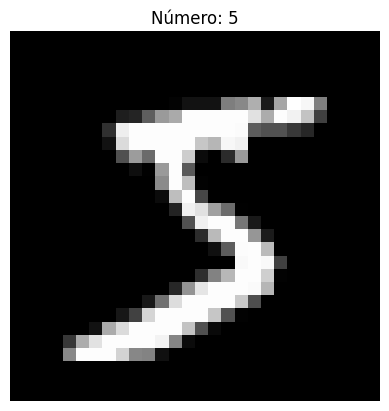

In [5]:
# Mostramos la primera imagen del conjunto de datos de entrenamiento.
plt.imshow(X_train[0], cmap="gray")

# Mostramos como título el número real que corresponde a la imagen.
plt.title("Número: " + str(y_train[0]))

# Ocultamos los ejes para que la imagen se vea más limpia.
plt.axis("off")

# Mostramos la imagen en pantalla.
plt.show()

In [6]:
# Creamos etiquetas nuevas donde el número 5 será la clase positiva.
y_train_5 = (y_train == 5).astype(int)

# Hacemos lo mismo con los datos de prueba para identificar los números 5.
y_test_5 = (y_test == 5).astype(int)

# Mostramos las primeras etiquetas para comprobar la transformación.
print("Primeras etiquetas:", y_train_5[:20])

Primeras etiquetas: [1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]


In [7]:
# Convertimos cada imagen de 28 por 28 píxeles en una sola fila de 784 valores.
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Hacemos la misma transformación con las imágenes de prueba.
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Dividimos los valores de los píxeles entre 255 para convertirlos a un rango entre 0 y 1.
X_train_flat = X_train_flat / 255.0

# Normalizamos también los valores de las imágenes de prueba.
X_test_flat = X_test_flat / 255.0

# Mostramos el nuevo tamaño de las imágenes de entrenamiento.
print("Nuevo tamaño de entrenamiento:", X_train_flat.shape)

# Mostramos el nuevo tamaño de las imágenes de prueba.
print("Nuevo tamaño de prueba:", X_test_flat.shape)

Nuevo tamaño de entrenamiento: (60000, 784)
Nuevo tamaño de prueba: (10000, 784)


In [8]:
# Creamos el modelo de regresión logística que aprenderá a reconocer el número 5.
modelo = LogisticRegression(max_iter=1000)

# Entrenamos el modelo utilizando las imágenes y las etiquetas que preparamos anteriormente.
modelo.fit(X_train_flat, y_train_5)

# Mostramos un mensaje para confirmar que el entrenamiento terminó correctamente.
print("El modelo terminó de entrenarse.")

El modelo terminó de entrenarse.


In [9]:
# Utilizamos el modelo entrenado para predecir si las imágenes de prueba son 5 o no son 5.
predicciones = modelo.predict(X_test_flat)

# Mostramos las primeras 20 predicciones realizadas por el modelo.
print("Primeras predicciones:", predicciones[:20])

# Mostramos las primeras 20 respuestas reales de las imágenes de prueba.
print("Valores reales:", y_test_5[:20])

Primeras predicciones: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
Valores reales: [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0]


In [10]:
# Calculamos el F1 Score para saber qué tan bien reconoce el modelo los números 5.
f1 = f1_score(y_test_5, predicciones)

# Mostramos el resultado del F1 Score.
print("F1 Score:", f1)

F1 Score: 0.8700764256319812


In [11]:
# Importamos pandas para poder crear una tabla con el resultado.
import pandas as pd

# Creamos una tabla que contiene el nombre de la métrica y su resultado.
tabla_f1 = pd.DataFrame({
    "Métrica": ["F1 Score"],
    "Resultado": [f1]
})

# Mostramos la tabla en el cuaderno.
display(tabla_f1)

,Métrica,Resultado
0,F1 Score,0.870076


In [12]:
# Obtenemos la probabilidad de que cada imagen pertenezca a la clase número 5.
probabilidades = modelo.predict_proba(X_test_flat)[:, 1]

# Calculamos la tasa de falsos positivos, la tasa de verdaderos positivos y los umbrales.
fpr, tpr, umbrales = roc_curve(y_test_5, probabilidades)

# Calculamos el área bajo la curva ROC para medir el rendimiento del modelo.
auc = roc_auc_score(y_test_5, probabilidades)

# Mostramos el valor del área bajo la curva ROC.
print("AUC de la curva ROC:", auc)

AUC de la curva ROC: 0.9758684278936766


In [13]:
# Creamos una tabla con los valores necesarios para construir la curva ROC.
tabla_roc = pd.DataFrame({
    "Umbral": umbrales,
    "Tasa de Falsos Positivos (FPR)": fpr,
    "Tasa de Verdaderos Positivos (TPR)": tpr
})

# Mostramos la tabla con los valores de la curva ROC.
display(tabla_roc)

,Umbral,Tasa de Falsos Positivos (FPR),Tasa de Verdaderos Positivos (TPR)
0,inf,0.000000,0.000000
1,9.999993e-01,0.000000,0.001121
2,9.995444e-01,0.000000,0.044843
3,9.994935e-01,0.000110,0.044843
4,9.977473e-01,0.000110,0.099776
...,...,...,...
367,2.477534e-07,0.943237,0.997758
368,2.410317e-07,0.943237,0.998879
369,1.318500e-07,0.950922,0.998879
370,1.312419e-07,0.950922,1.000000


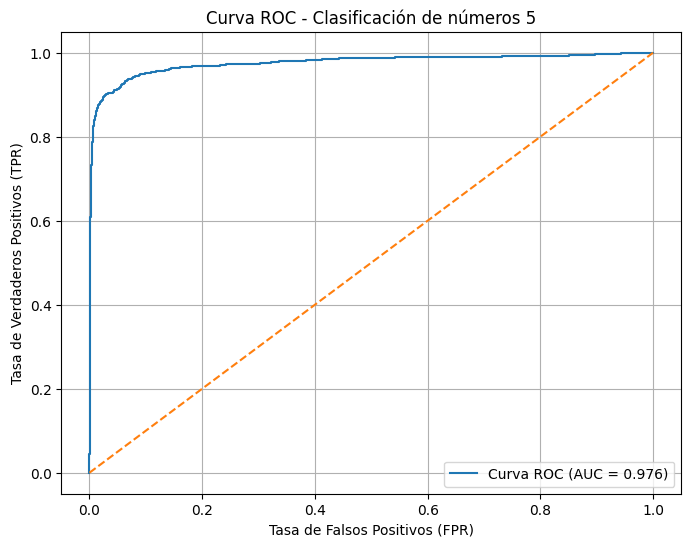

In [14]:
# Creamos el espacio donde se mostrará la gráfica de la curva ROC.
plt.figure(figsize=(8, 6))

# Dibujamos la curva ROC utilizando la tasa de falsos positivos y verdaderos positivos.
plt.plot(fpr, tpr, label="Curva ROC (AUC = {:.3f})".format(auc))

# Dibujamos una línea diagonal que representa un clasificador sin capacidad de distinguir las clases.
plt.plot([0, 1], [0, 1], "--")

# Colocamos el nombre del eje horizontal.
plt.xlabel("Tasa de Falsos Positivos (FPR)")

# Colocamos el nombre del eje vertical.
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")

# Colocamos el título de la gráfica.
plt.title("Curva ROC - Clasificación de números 5")

# Mostramos la leyenda con el valor del AUC.
plt.legend()

# Activamos una cuadrícula para facilitar la lectura de la gráfica.
plt.grid()

# Mostramos la gráfica.
plt.show()

## Conclusión

En este ejercicio se utilizó el conjunto de datos MNIST para entrenar un modelo de Regresión Logística capaz de identificar si una imagen corresponde al número 5 o a otro número. Las imágenes fueron transformadas de 28 × 28 píxeles a 784 valores y sus datos fueron normalizados para facilitar el entrenamiento.

El modelo obtuvo un **F1 Score de 0.8701**, lo que muestra un buen desempeño en la clasificación. Además, se obtuvo un **AUC de 0.9759** en la curva ROC, indicando que el modelo tiene una alta capacidad para diferenciar los números 5 de los demás números.

Por medio de este ejercicio se pudo observar cómo un modelo de aprendizaje automático puede aprender a reconocer patrones en imágenes y cómo las métricas F1 Score y ROC-AUC permiten evaluar su desempeño.
